The Mission has 2 Phases.  

In Phase 1, you will work as a team on ANZ Bank analytics challenge.  The teams will be created by the trainer.

In Phase 2, you will prepare for submission, including both team submission and individual submission.




Dataset Overview:
The dataset consists of the following columns:

 person_age: Age of the person applying for the loan.

 person_gender: Gender of the applicant.

 person_education: Education level of the applicant.

 person_income: Income of the applicant.

 person_emp_exp: Years of employment experience.

 person_home_ownership: Type of home ownership (Rent, Own, Mortgage).

loan_amnt: Amount of the loan applied for.

loan_intent: Purpose of the loan (e.g., Personal, Education, Medical).

loan_int_rate: Interest rate on the loan.

loan_percent_income: Percentage of income used for the loan.

cb_person_cred_hist_length: Length of the applicant's credit history.

credit_score: Credit score of the applicant.

previous_loan_defaults_on_file: Whether the applicant has previous loan defaults.

loan_status: Target variable (1 = Loan defaulted, 0 = Loan approved).
 

The goal is to predict loan_status (whether the loan will be approved or defaulted) using the features provided.


**Load the Dataset**

• Load the Final_Mission_loan_data.csv from the container in Azure Blob Storage using the following credentials:

Connection String:


connect_str =
"DefaultEndpointsProtocol=https;AccountName=level5data;AccountKey=cWgxWhPELQdrW0sIgA/eXM8/k9+xdaELukN8sg5imfhm4wVIJQFmypEph/Ppy500v41mYT+iCBbC+AStsfHbAQ==;EndpointSuffix=core.windows.net"


container_name = “businesscases”
blob_name = "Final_Mission_loan_data.csv"

In [ ]:
connect_str = "DefaultEndpointsProtocol=https;AccountName=level5data;AccountKey=cWgxWhPELQdrW0sIgA/eXM8/k9+xdaELukN8sg5imfhm4wVIJQFmypEph/Ppy500v41mYT+iCBbC+AStsfHbAQ==;EndpointSuffix=core.windows.net"
container_name = "businesscases"
blob_name = "Final_Mission_loan_data.csv"

StatementMeta(, bb68f46c-40f0-412e-8039-b4545f46bbf1, 5, Finished, Available, Finished, False)

In [ ]:
import pandas as pd
from azure.storage.blob import BlobServiceClient
from io import StringIO

# Azure Blob Storage connection string
connect_str = "DefaultEndpointsProtocol=https;AccountName=level5data;AccountKey=cWgxWhPELQdrW0sIgA/eXM8/k9+xdaELukN8sg5imfhm4wVIJQFmypEph/Ppy500v41mYT+iCBbC+AStsfHbAQ==;EndpointSuffix=core.windows.net"
container_name = "businesscases"
blob_name = "Final_Mission_loan_data.csv"

# Create a BlobServiceClient using the connection string
blob_service_client = BlobServiceClient.from_connection_string(connect_str)

# Get the container client
container_client = blob_service_client.get_container_client(container_name)

# Get the blob client for the specific file
blob_client = container_client.get_blob_client(blob_name)

# Download the blob as a string
blob_data = blob_client.download_blob()
csv_content = blob_data.readall().decode('utf-8')

# Convert the CSV string to a pandas DataFrame
df = pd.read_csv(StringIO(csv_content))

# Display the first few rows
display(df)

StatementMeta(, bb68f46c-40f0-412e-8039-b4545f46bbf1, 6, Finished, Available, Finished, False)

SynapseWidget(Synapse.DataFrame, 0b66141a-1548-4f54-a87f-0bfb639148c5)

**Perform Exploratory Data Analysis (EDA)**

 Inspect the dataset for missing values and data types.

Visualise the distribution of loan amounts, credit scores, and loan statuses.

 Check for correlations between features and the target variable (loan_status).
 



In [ ]:
df.isna().sum()

StatementMeta(, bb68f46c-40f0-412e-8039-b4545f46bbf1, 7, Finished, Available, Finished, False)

person_age                        0
person_gender                     0
person_education                  0
person_income                     0
person_emp_exp                    0
person_home_ownership             0
loan_amnt                         0
loan_intent                       0
loan_int_rate                     0
loan_percent_income               0
cb_person_cred_hist_length        0
credit_score                      0
previous_loan_defaults_on_file    0
loan_status                       0
dtype: int64

****

In [ ]:
df.info()

StatementMeta(, bb68f46c-40f0-412e-8039-b4545f46bbf1, 8, Finished, Available, Finished, False)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 45000 entries, 0 to 44999
Data columns (total 14 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   person_age                      45000 non-null  int64  
 1   person_gender                   45000 non-null  object 
 2   person_education                45000 non-null  object 
 3   person_income                   45000 non-null  int64  
 4   person_emp_exp                  45000 non-null  int64  
 5   person_home_ownership           45000 non-null  object 
 6   loan_amnt                       45000 non-null  int64  
 7   loan_intent                     45000 non-null  object 
 8   loan_int_rate                   45000 non-null  float64
 9   loan_percent_income             45000 non-null  float64
 10  cb_person_cred_hist_length      45000 non-null  int64  
 11  credit_score                    45000 non-null  int64  
 12  previous_loan_defaults_on_file  

**Based on the above outcome we can conclude that the data is free of any null values.**

In [ ]:
df.describe()

StatementMeta(, bb68f46c-40f0-412e-8039-b4545f46bbf1, 9, Finished, Available, Finished, False)

,person_age,person_income,person_emp_exp,loan_amnt,loan_int_rate,loan_percent_income,cb_person_cred_hist_length,credit_score,loan_status
count,45000.000000,4.500000e+04,45000.000000,45000.000000,45000.000000,45000.000000,45000.000000,45000.000000,45000.000000
mean,27.764178,8.031905e+04,5.410333,9583.157556,11.006606,0.139725,5.867489,632.608756,0.222222
std,6.045108,8.042250e+04,6.063532,6314.886691,2.978808,0.087212,3.879702,50.435865,0.415744
min,20.000000,8.000000e+03,0.000000,500.000000,5.420000,0.000000,2.000000,390.000000,0.000000
25%,24.000000,4.720400e+04,1.000000,5000.000000,8.590000,0.070000,3.000000,601.000000,0.000000
50%,26.000000,6.704800e+04,4.000000,8000.000000,11.010000,0.120000,4.000000,640.000000,0.000000
75%,30.000000,9.578925e+04,8.000000,12237.250000,12.990000,0.190000,8.000000,670.000000,0.000000
max,144.000000,7.200766e+06,125.000000,35000.000000,20.000000,0.660000,30.000000,850.000000,1.000000


**For deeper understanding of data, we use describe function**

StatementMeta(, bb68f46c-40f0-412e-8039-b4545f46bbf1, 10, Finished, Available, Finished, False)

/home/trusted-service-user/cluster-env/trident_env/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


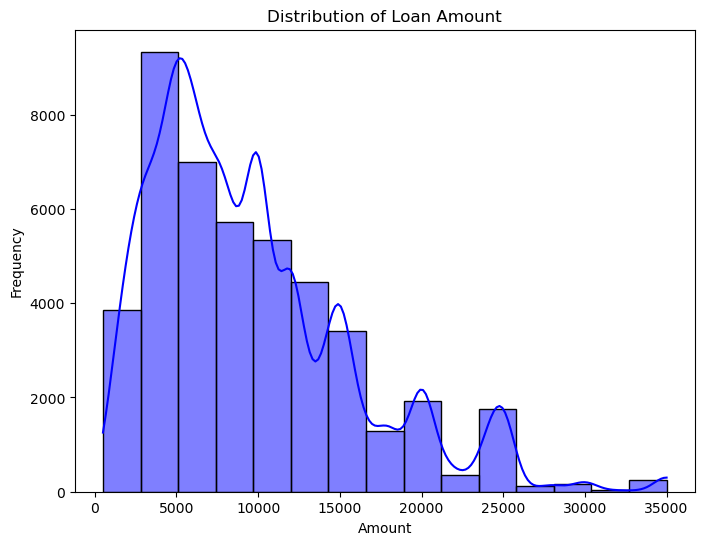

/home/trusted-service-user/cluster-env/trident_env/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


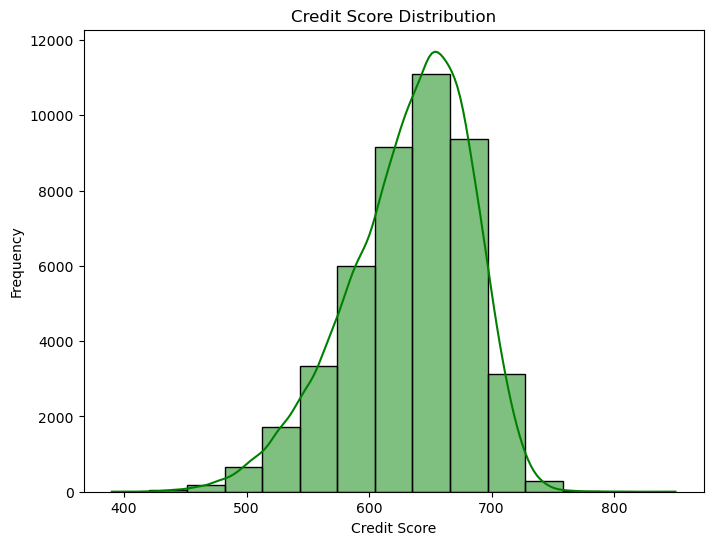

/home/trusted-service-user/cluster-env/trident_env/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


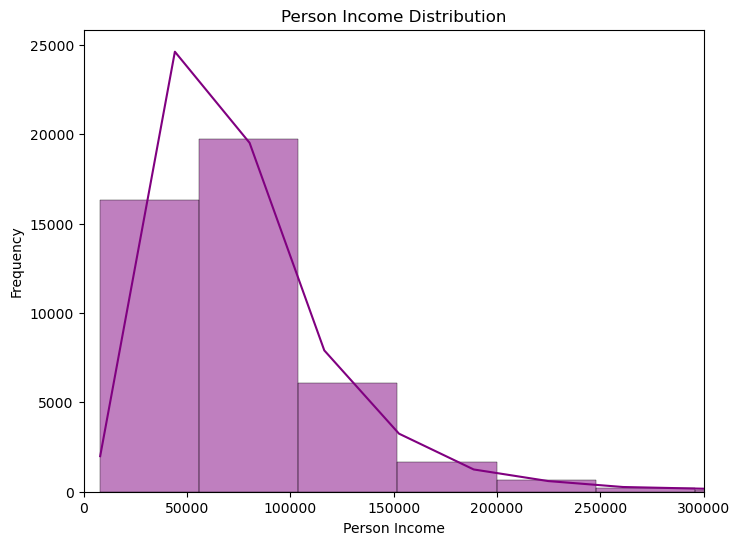

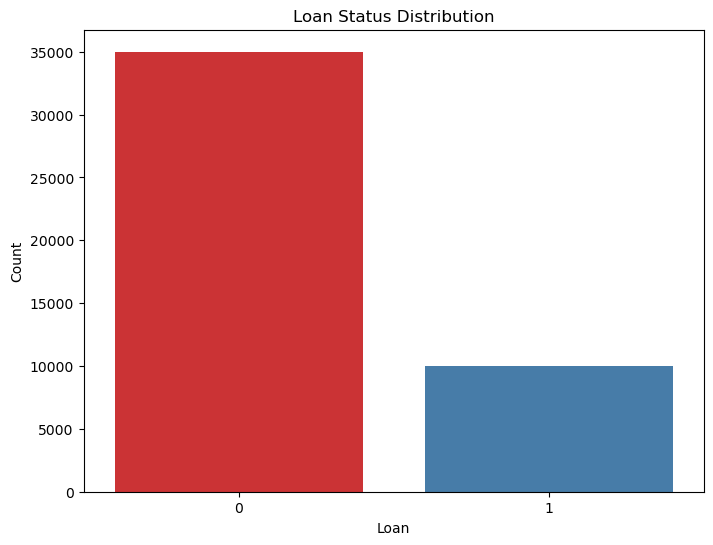

In [ ]:
## Visualise the distribution of loan amounts, credit scores, and loan status.

import seaborn as sns
import matplotlib.pyplot as plt

# Loan amount distribution
plt.figure(figsize=(8, 6))
sns.histplot(df['loan_amnt'], bins=15, kde=True, color='blue')
plt.title('Distribution of Loan Amount')
plt.xlabel('Amount')
plt.ylabel('Frequency')
plt.show()

# Credit score distribution
plt.figure(figsize=(8, 6))
sns.histplot(df['credit_score'], bins=15, kde=True, color='green')
plt.title('Credit Score Distribution')
plt.xlabel('Credit Score')
plt.ylabel('Frequency')
plt.show()

# Income distribution
plt.figure(figsize=(8, 6))
sns.histplot(df['person_income'], bins=150, kde=True, color='purple')
plt.xlim(0,300000)
plt.title('Person Income Distribution')
plt.xlabel('Person Income')
plt.ylabel('Frequency')
plt.show()

# Churn distribution (target variable)
plt.figure(figsize=(8, 6))
sns.countplot(x='loan_status', data=df, palette='Set1')
plt.title('Loan Status Distribution')
plt.xlabel('Loan')
plt.ylabel('Count')
plt.show()



**Loan Amount Distribution**

The histogram shows that most customers take small to medium loans, mainly between $3,000 and $12,000.

while large loans above $20,000 are much less common, resulting in a right-skewed distribution.


**Credit score Distribution**

The histogram shows the distribution of credit scores among borrowers.

Most credit scores fall between 600 and 700, with the highest concentration around 650, indicating that many borrowers have moderate credit scores.

The distribution appears approximately normal (bell-shaped), with fewer borrowers having very low or very high credit scores.

**Income Distribution Explanation**

The income distribution is positively skewed, with most individuals earning between 30,000 and 100,000.

A small proportion of individuals have significantly higher incomes, creating a long right tail.

This indicates the presence of high-income outliers.

**CountPlot**

The number of applicants with loan status 0 (approved) is significantly higher than those with loan status 1 (not approved).

This indicates that most loan applications in the dataset were approved, while a smaller proportion were rejected.


**Correlation Heatmap**

Let’s visualize the correlations between features and the target variable (loan_status).

StatementMeta(, bb68f46c-40f0-412e-8039-b4545f46bbf1, 11, Finished, Available, Finished, False)

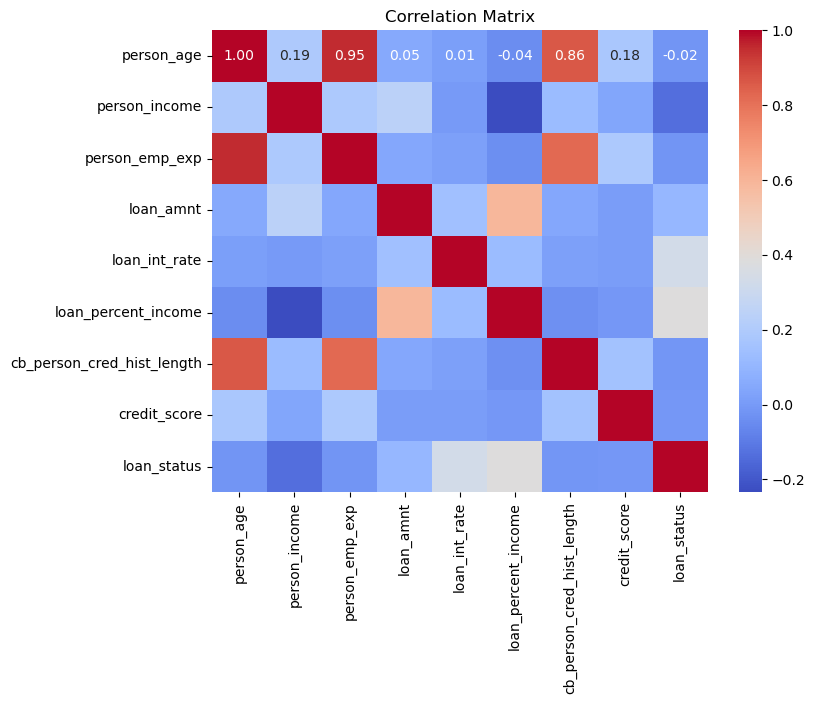

In [ ]:
# Select only numeric columns for correlation
numeric_df = df.select_dtypes(include=['float64', 'int64'])

# Calculate the correlation matrix
correlation_matrix = numeric_df.corr()

# Heatmap of correlations
plt.figure(figsize=(8, 6))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Matrix')
plt.show()

**Positive Correlation**

person_age ↔ person_emp_exp (0.95): As age increases, employment experience also increases.

person_age ↔ cb_person_cred_hist_length (0.86): Older people tend to have a longer credit history.

loan_amnt ↔ loan_percent_income (~0.60): Higher loan amounts usually take up a larger percentage of a person’s income.


**Negative Correlation**

person_income ↔ loan_percent_income (~-0.25): People with higher income spend a smaller percentage of their income on loans.

person_income ↔ loan_status (negative): Higher income slightly reduces the likelihood of negative loan outcomes.

loan_int_rate ↔ person_income (negative): Individuals with higher income tend to have slightly lower interest rates.

**Data Preprocessing**

Clean and preprocess the data:

Handle missing values (if any).

Encode categorical variables such as person_gender, person_education, and person_home_ownership.

Split the data into features (X) and target (y).

Split the data into training and testing sets.

**Based on the above outcome we can conclude that the data is free of any null values.**


In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

# Encode categorical columns (e.g., person_gender, person_education and person_home_ownership)
label_encoder = LabelEncoder()
df['person_gender'] = label_encoder.fit_transform(df['person_gender'])
df['person_education'] = label_encoder.fit_transform(df['person_education'])
df['person_home_ownership'] = label_encoder.fit_transform(df['person_home_ownership'])

# Features (x) and target (y)
X = df[['person_age', 'person_income', 'person_emp_exp', 'loan_amnt', 'loan_int_rate', 'loan_percent_income', 'credit_score', 'person_gender', 
        'person_education', 'person_home_ownership']]
y = df[['loan_status']]


StatementMeta(, bb68f46c-40f0-412e-8039-b4545f46bbf1, 12, Finished, Available, Finished, False)

**Split Data into Training and Test Sets**

We will split the data into training (80%) and testing (20%) sets.

In [ ]:
# Split the data into training and testing sets (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

StatementMeta(, bb68f46c-40f0-412e-8039-b4545f46bbf1, 13, Finished, Available, Finished, False)

**Train Multiple Models**

• Train the following models to predict loan defaults:

1. Logistic Regression:  This is a common model for binary classification tasks. It will predict whether a loan will default (1) or be approved (0).

2. Random Forest Classifier: This model can capture non-linear patterns and interactions between features.

3. Additional Model of Your Choice: Research another classification model that might perform better than the above two. This could be Gradient Boosting, XGBoost, or any other model you find suitable for the task. 

**Train Logistic Regression Model**

Let’s train a Logistic Regression model to predict loan defaults.

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix

# Initialize Logistic Regression model
log_reg_model = LogisticRegression()

# Train the model
log_reg_model.fit(X_train, y_train)

# Predict on the test set
y_pred_log_reg = log_reg_model.predict(X_test)

# Evaluate the model
log_reg_accuracy = accuracy_score(y_test, y_pred_log_reg)
print(f"Logistic Regression Accuracy: {log_reg_accuracy}")

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred_log_reg)

StatementMeta(, bb68f46c-40f0-412e-8039-b4545f46bbf1, 14, Finished, Available, Finished, False)

/home/trusted-service-user/cluster-env/trident_env/lib/python3.11/site-packages/sklearn/utils/validation.py:1143: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


Logistic Regression Accuracy: 0.791


In [ ]:
results_df = pd.DataFrame({
    'Actual Loan Default': y_test.squeeze(),
    'Predicted Loan Default (Logistic Regression)': y_pred_log_reg})
display(results_df)

StatementMeta(, bb68f46c-40f0-412e-8039-b4545f46bbf1, 15, Finished, Available, Finished, False)

SynapseWidget(Synapse.DataFrame, 14a05d63-2a94-438f-a405-63bb9ebfc840)

In [ ]:
import pandas as pd

log_reg_accuracy = accuracy_score(y_test, y_pred_log_reg)
print(f"Logistic Regression Accuracy: {log_reg_accuracy}")

cm = confusion_matrix(y_test, y_pred_log_reg, labels=[0, 1])
cm_df = pd.DataFrame(cm,
                     index=["Actual: 0 (Negative)", "Actual: 1 (Positive)"],
                     columns=["Predicted: 0 (Negative)", "Predicted: 1 (Positive)"])
print(cm_df)

StatementMeta(, bb68f46c-40f0-412e-8039-b4545f46bbf1, 16, Finished, Available, Finished, False)

Logistic Regression Accuracy: 0.791
                      Predicted: 0 (Negative)  Predicted: 1 (Positive)
Actual: 0 (Negative)                     6875                      115
Actual: 1 (Positive)                     1766                      244


**Confusion Matrix and Accuracy - Explanation**

 **Confusion Matrix**:

A **confusion matrix** compares the **actual** vs **predicted** values to show where the model got things right or wrong:

| Actual \ Predicted | Predicted: Negative | Predicted: Positive |
| ------------------ | ------------------- | ------------------- |
| **Actual: Negative** | True Negative (TN) – Correctly predicted negative | False Positive (FP) – Wrongly predicted positive |
| **Actual: Positive** | False Negative (FN) – Missed positive | True Positive (TP) – Correctly predicted positive |


**Accuracy**: Accuracy is the percentage of correct predictions made by the model. It is calculated as:

$$
\text{Accuracy} = \frac{TP + TN}{TP + TN + FP + FN}
$$


**Outcome of Logistic Regression Model**

Good at identifying safe borrowers,not very good at identifying defaulters

Because:

Only 244 defaults correctly predicted,whereas 1766 defaults missed

So the model approves many risky loans.

The Logistic Regression model achieved an accuracy of 79.1%, indicating that the model correctly predicts the loan outcome in most cases.

However, the confusion matrix shows that the model struggles to correctly identify loan defaults. 

While it accurately predicts a large number of non-default cases (6875), it misclassifies many default cases (1766) as non-default.
 
This suggests that the model may not be highly reliable for identifying risky borrowers and improvements may be needed to better detect potential loan defaults.

**Train Random Forest Model**

Let’s train a Random Forest Regressor model and compare it to Logistic Regression.

In [ ]:
from sklearn.ensemble import RandomForestClassifier

# Initialize Random Forest model
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)

# Train the model
rf_model.fit(X_train, y_train)

# Predict on the test set
y_pred_rf = rf_model.predict(X_test)

# Evaluate the model
rf_accuracy = accuracy_score(y_test, y_pred_rf)
print(f"Random Forest Accuracy: {rf_accuracy}")

# Confusion Matrix

cm_rf = confusion_matrix(y_test, y_pred_rf, labels=[0, 1])
cm_rf = pd.DataFrame(cm_rf,
                     index=["Actual: 0 (Negative)", "Actual: 1 (Positive)"],
                     columns=["Predicted: 0 (Negative)", "Predicted: 1 (Positive)"])
print(cm_rf)

StatementMeta(, bb68f46c-40f0-412e-8039-b4545f46bbf1, 17, Finished, Available, Finished, False)

Random Forest Accuracy: 0.893
                      Predicted: 0 (Negative)  Predicted: 1 (Positive)
Actual: 0 (Negative)                     6787                      203
Actual: 1 (Positive)                      760                     1250



**Outcome of Random Forest Model**

The Random Forest model achieved an accuracy of 89.3%. 

It correctly classified 6787 approved loans and 1250 defaulted loans. 

However, 760 defaulted loans were incorrectly predicted as approved, which represents a potential financial risk for lenders.

Overall, the model performs well but could be improved to better detect defaulted loans.

**Tuned Random Forest Model**

Let's adjust the Random Forest parameters with 150 estimators and train again.

In [ ]:
## Tuning with 150 Estimators 

# Initialize Random Forest model with adjusted parameters
rf_model_tuned_150 = RandomForestClassifier(n_estimators= 150, random_state=42)

# Train the model
rf_model_tuned_150.fit(X_train, y_train)

# Predict on the test set
y_pred_rf_tuned_150 = rf_model_tuned_150.predict(X_test)

# Evaluate the model
rf_tuned_accuracy_150 = accuracy_score(y_test, y_pred_rf_tuned_150)
print(f"Random Forest (Tuned 150 n estimators) Accuracy: {rf_tuned_accuracy_150}")

# Confusion Matrix

cm_rf_tuned_150 = confusion_matrix(y_test, y_pred_rf_tuned_150, labels=[0, 1])
cm_rf_tuned_150 = pd.DataFrame(cm_rf_tuned_150,
                     index=["Actual: 0 (Negative)", "Actual: 1 (Positive)"],
                     columns=["Predicted: 0 (Negative)", "Predicted: 1 (Positive)"])
print(cm_rf_tuned_150)

StatementMeta(, bb68f46c-40f0-412e-8039-b4545f46bbf1, 18, Finished, Available, Finished, False)

Random Forest (Tuned 150 n estimators) Accuracy: 0.8938888888888888
                      Predicted: 0 (Negative)  Predicted: 1 (Positive)
Actual: 0 (Negative)                     6789                      201
Actual: 1 (Positive)                      754                     1256


**Outcome of Random Forest(tuned 150 n estimators)**

The tuned Random Forest model (150 estimators) achieved an accuracy of 89.39%, indicating strong overall performance in predicting loan outcomes. 

The model correctly classified 6789 approved loans and 1256 defaulted loans.

However, 201 approved loans were incorrectly predicted as defaulted, and 754 defaulted loans were predicted as approved.

While the model performs well overall, the false negatives (defaulted loans predicted as approved) may pose a financial risk to lenders.

**Let's adjust the Random Forest parameters with 300 n estimators and train again.**

In [ ]:
### Tunning the model with 300 Estimators

# Initialize Random Forest model with adjusted parameters
rf_model_tuned_300 = RandomForestClassifier(n_estimators= 300, random_state=42)

# Train the model
rf_model_tuned_300.fit(X_train, y_train)

# Predict on the test set
y_pred_rf_tuned_300 = rf_model_tuned_300.predict(X_test)

# Evaluate the model
rf_tuned_accuracy_300 = accuracy_score(y_test, y_pred_rf_tuned_300)
print(f"Random Forest (Tuned 300 n estimators) Accuracy: {rf_tuned_accuracy_300}")

# Confusion Matrix

cm_rf_tuned_300 = confusion_matrix(y_test, y_pred_rf_tuned_300, labels=[0, 1])
cm_rf_tuned_300 = pd.DataFrame(cm_rf_tuned_300,
                     index=["Actual: 0 (Negative)", "Actual: 1 (Positive)"],
                     columns=["Predicted: 0 (Negative)", "Predicted: 1 (Positive)"])
print(cm_rf_tuned_300)

StatementMeta(, bb68f46c-40f0-412e-8039-b4545f46bbf1, 19, Finished, Available, Finished, False)

Random Forest (Tuned 300 n estimators) Accuracy: 0.8942222222222223
                      Predicted: 0 (Negative)  Predicted: 1 (Positive)
Actual: 0 (Negative)                     6791                      199
Actual: 1 (Positive)                      753                     1257


**Outcome of Random Forest tunned with 300 estimators**

The tuned Random Forest model with 300 estimators achieved an accuracy of 89.42%,showing slightly improved performance compared to other models. 

It correctly predicted 6791 approved loans and 1257 defaulted loans. However, 199 approved loans were incorrectly classified as defaulted, and 753 defaulted loans were predicted as approved. 

Overall, the model performs well in identifying approved loans but still misclassifies some defaulted cases, which could lead to financial risk for lenders.

**Additional Model of Your Choice:**

Research another classification model that might perform better than the above two. This could be Gradient Boosting, XGBoost, or any other model you find suitable for the task.

For this analysis we used Gradient Boosting.

For a loan approval / loan default classification problem, a very good third model is Gradient Boosting. It is commonly used in finance because it handles complex patterns better than Logistic Regression and Decision Trees.

Since XGBoost may require extra installation, the safest and easiest option is Gradient Boosting using Scikit-learn.

In [ ]:
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.metrics import accuracy_score, confusion_matrix

# Create the model
gb_model = GradientBoostingClassifier(random_state=42)

# Train the model
gb_model.fit(X_train, y_train)

# Make predictions
y_pred_gb = gb_model.predict(X_test)

# Calculate accuracy
accuracy_gb = accuracy_score(y_test, y_pred_gb)

print("Gradient Boosting Accuracy:", accuracy_gb)

StatementMeta(, bb68f46c-40f0-412e-8039-b4545f46bbf1, 20, Finished, Available, Finished, False)

/home/trusted-service-user/cluster-env/trident_env/lib/python3.11/site-packages/sklearn/ensemble/_gb.py:437: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


Gradient Boosting Accuracy: 0.8895555555555555


In [ ]:
import pandas as pd

# Calculate accuracy
accuracy_gb = accuracy_score(y_test, y_pred_gb)

print("Gradient Boosting Accuracy:", accuracy_gb)

# Confusion Matrix
cm_gb = confusion_matrix(y_test, y_pred_gb)

cm_df = pd.DataFrame(
    cm_gb,
    index=["Actual: 0 (Negative)", "Actual: 1 (Positive)"],
    columns=["Predicted: 0 (Negative)", "Predicted: 1 (Positive)"]
)

print(cm_df)

StatementMeta(, bb68f46c-40f0-412e-8039-b4545f46bbf1, 21, Finished, Available, Finished, False)

Gradient Boosting Accuracy: 0.8895555555555555
                      Predicted: 0 (Negative)  Predicted: 1 (Positive)
Actual: 0 (Negative)                     6772                      218
Actual: 1 (Positive)                      776                     1234


**Outcome of Gradient Boosting Model**

The Gradient Boosting model achieved an accuracy of 88.96%, indicating that it correctly predicted most loan outcomes in the dataset.

The confusion matrix shows that the model correctly identified 6772 safe loans (true negatives) and 1234 loan defaults (true positives).

However, it incorrectly predicted 218 safe loans as defaults (false positives) and 776 default cases as safe loans (false negatives).

Compared to simpler models, Gradient Boosting performs better at capturing complex patterns in the data and detecting loan defaults. This makes it a reliable model for predicting loan risk and supporting better decision-making in loan approval systems.

**Model Accuracy Comparison**

Compare the accuracy of the Logistic Regression, Random Forest and Gradient Boosting models.

In [ ]:
# Compare the accuracy of all models
print(f"Logistic Regression Accuracy: {log_reg_accuracy}")
print(f"Random Forest 100 Estimators: {rf_accuracy}")
print(f"Tuned Random Forest Accuracy 150 Estimators: {rf_tuned_accuracy_150}")
print(f"Tuned Random Forest Accuracy 300 Estimators: {rf_tuned_accuracy_300}")
print(f"Gradient Boosting Accuracy: {accuracy_gb}")

StatementMeta(, bb68f46c-40f0-412e-8039-b4545f46bbf1, 22, Finished, Available, Finished, False)

Logistic Regression Accuracy: 0.791
Random Forest 100 Estimators: 0.893
Tuned Random Forest Accuracy 150 Estimators: 0.8938888888888888
Tuned Random Forest Accuracy 300 Estimators: 0.8942222222222223
Gradient Boosting Accuracy: 0.8895555555555555



**Model Accuracy Comparison Summary**

Among the three models tested, Random Forest performed the best. 

It achieved the highest accuracy of 89.4% and correctly identified 1257 loan default cases, which is higher than Gradient Boosting and Logistic Regression.

Additionally, it produced fewer missed default predictions compared to the other models.

This indicates that Random Forest is more effective at identifying risky borrowers and is therefore the most suitable model for loan default prediction in this dataset.


In [ ]:
## Compare the performance of all models using Confusion Matrix (Error Matrix)

cm = confusion_matrix(y_test, y_pred_log_reg, labels=[0, 1])
cm_df = pd.DataFrame(cm,
                     index=["Actual: 0 (Negative)", "Actual: 1 (Positive)"],
                     columns=["Predicted: 0 (Negative)", "Predicted: 1 (Positive)"])
print("Confusion Matrix of Logistic Regression:")

print(cm_df)
 
cm_rf = confusion_matrix(y_test, y_pred_rf, labels=[0, 1])  
cm_rf = pd.DataFrame(cm_rf,
                     index=["Actual: 0 (Negative)", "Actual: 1 (Positive)"],
                     columns=["Predicted: 0 (Negative)", "Predicted: 1 (Positive)"])
                   
print("Confusion Matrix of Random Forest 100 Estimators:")

print(cm_rf)

cm_rf_tuned_150 = confusion_matrix(y_test, y_pred_rf_tuned_150, labels=[0, 1])
cm_rf_tuned_150= pd.DataFrame(cm_rf_tuned_150,
                     index=["Actual: 0 (Negative)", "Actual: 1 (Positive)"],
                     columns=["Predicted: 0 (Negative)", "Predicted: 1 (Positive)"])
                     
print("Confusion Matrix of Tuned Random Forest 150 Estimators")

print(cm_rf_tuned_150)

cm_rf_tuned_300 = confusion_matrix(y_test, y_pred_rf_tuned_300, labels=[0, 1])
cm_rf_tuned_300= pd.DataFrame(cm_rf_tuned_300,
                     index=["Actual: 0 (Negative)", "Actual: 1 (Positive)"],
                     columns=["Predicted: 0 (Negative)", "Predicted: 1 (Positive)"])
                     
print("Confusion Matrix of Tuned Random Forest 300 Estimators")

print(cm_rf_tuned_300)

cm_gb = confusion_matrix(y_test, y_pred_gb)
cm_df = pd.DataFrame(
    cm_gb,
    index=["Actual: 0 (Negative)", "Actual: 1 (Positive)"],
    columns=["Predicted: 0 (Negative)", "Predicted: 1 (Positive)"]
)

print("Confusion Matrix of Gradient Boosting:")
print(cm_df)



StatementMeta(, bb68f46c-40f0-412e-8039-b4545f46bbf1, 23, Finished, Available, Finished, False)

Confusion Matrix of Logistic Regression:
                      Predicted: 0 (Negative)  Predicted: 1 (Positive)
Actual: 0 (Negative)                     6875                      115
Actual: 1 (Positive)                     1766                      244
Confusion Matrix of Random Forest 100 Estimators:
                      Predicted: 0 (Negative)  Predicted: 1 (Positive)
Actual: 0 (Negative)                     6787                      203
Actual: 1 (Positive)                      760                     1250
Confusion Matrix of Tuned Random Forest 150 Estimators
                      Predicted: 0 (Negative)  Predicted: 1 (Positive)
Actual: 0 (Negative)                     6789                      201
Actual: 1 (Positive)                      754                     1256
Confusion Matrix of Tuned Random Forest 300 Estimators
                      Predicted: 0 (Negative)  Predicted: 1 (Positive)
Actual: 0 (Negative)                     6791                      199
Actual: 1 (Positiv

**Model Comparison**

Compare the results of all three models based on the evaluation metrics.

In [ ]:
# Create a DataFrame for Actual vs Predicted default loans for both models
df_results = pd.DataFrame({
    'Actual Loan Defaults': y_test.squeeze(),
    'Predicted Loan Defaults (Logistic Regression)': y_pred_log_reg,
    'Predicted Loan Defaults (Random Forest 100 Estimators)': y_pred_rf,
    'Predicted Loan Defaults (Random Forest Tuned 150 estimators)': y_pred_rf_tuned_150,
    'Predicted Loan Defaults (Random Forest Tuned 300 estimators)': y_pred_rf_tuned_300,
    'Predicted Loan Defaults (Gradient Boosting)': y_pred_gb
})

# Display the table
display(df_results)

StatementMeta(, bb68f46c-40f0-412e-8039-b4545f46bbf1, 24, Finished, Available, Finished, False)

SynapseWidget(Synapse.DataFrame, a98c58b2-1ede-4854-bf5e-c0832d5f8f87)

Save the result in the dataframe named: df_results

In [ ]:
# Import necessary libraries
from pyspark.sql import SparkSession

# Create or get the existing Spark session
spark = SparkSession.builder \
    .appName("PySpark Basic Example") \
    .getOrCreate()

# Check the Spark version
print(f"Spark Version: {spark.version}")

StatementMeta(, bb68f46c-40f0-412e-8039-b4545f46bbf1, 25, Finished, Available, Finished, False)

Spark Version: 3.5.5.5.4.20260211.1


In [ ]:
df_results_spark = spark.createDataFrame(df_results)

StatementMeta(, bb68f46c-40f0-412e-8039-b4545f46bbf1, 26, Finished, Available, Finished, False)

In [ ]:
df_results_spark.createOrReplaceTempView("df_results_spark_view")

StatementMeta(, bb68f46c-40f0-412e-8039-b4545f46bbf1, 27, Finished, Available, Finished, False)

In [ ]:
df = spark.sql("SELECT * FROM Team3_lakehouse.dbo.Team3_Mission5 LIMIT 1000")
display(df)

StatementMeta(, bb68f46c-40f0-412e-8039-b4545f46bbf1, 28, Finished, Available, Finished, False)

SynapseWidget(Synapse.DataFrame, bb4580b1-b7b2-4a2d-8477-4a8819ac7efb)

In [ ]:
df_spark= spark.table("df_results_spark_view")

StatementMeta(, bb68f46c-40f0-412e-8039-b4545f46bbf1, 29, Finished, Available, Finished, False)

In [ ]:
df_spark.write.mode("overwrite").option("overwriteSchema", "true").format("delta").saveAsTable("Team3_Mission5")

StatementMeta(, bb68f46c-40f0-412e-8039-b4545f46bbf1, 30, Finished, Available, Finished, False)

Conclusion

Based on the performance, conclude which model is best for predicting loan defaults and provide insights on how this model could help the bank in its decision-making process.

Random Forest performed the best among the three models because it is an ensemble learning method that combines multiple decision trees to improve prediction accuracy and reduce overfitting. By averaging the predictions from many trees, Random Forest can capture complex relationships between variables in the dataset. This makes it particularly effective for financial risk prediction tasks such as loan default detection, where multiple factors influence the outcome.

This model can help banks make better lending decisions by accurately predicting which customers are more likely to default on their loans. By identifying high-risk applicants in advance, the bank can reduce financial losses and improve its credit risk management process. As a result, Random Forest provides a more effective and reliable approach for supporting loan approval decisions.